# Streaming, decay & persistence

The `Betula` estimator is **out-of-core**: feed data in chunks with `partial_fit`, finalize, then
`predict`. Memory stays bounded by `max_leaves` no matter how much streams through. `decay`
down-weights old data for concept drift, and a fitted model serializes via `save`/`load` + pickle.

In [1]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.metrics import adjusted_rand_score as ari

import betula_cluster
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", palette="deep")

X, y = make_blobs(n_samples=60_000, centers=5, cluster_std=0.7, random_state=0)
X = X.astype(np.float64)

## Streaming `partial_fit`

Feed 12 chunks; a final no-arg `partial_fit()` runs the global clustering over everything seen
(scikit-learn-Birch style). Peak memory is set by `max_leaves`, not by the stream length.

streaming ARI = 0.971   n_leaves_ = 395   n_rebuilds_ = 5


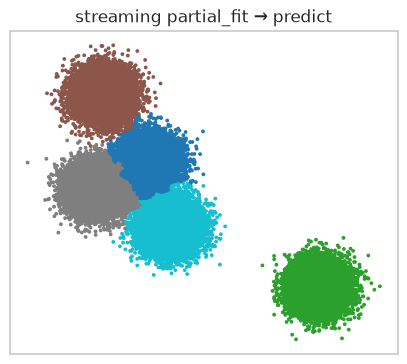

In [2]:
est = betula_cluster.Betula(n_clusters=5, feature="diagonal", method="gmm", max_leaves=500)
order = np.random.default_rng(0).permutation(len(X))
for chunk in np.array_split(order, 12):
    est.partial_fit(X[chunk])
est.partial_fit()  # finalize
labels = est.predict(X)
print(f"streaming ARI = {ari(y, labels):.3f}   n_leaves_ = {est.n_leaves_}   n_rebuilds_ = {est.n_rebuilds_}")

plt.figure(figsize=(5, 4.2))
plt.scatter(X[:, 0], X[:, 1], c=labels, s=3, cmap="tab10")
plt.title("streaming partial_fit → predict")
plt.xticks([])
plt.yticks([])
plt.show()

## Persistence — `save` / `load` and pickle

A fitted model round-trips exactly (CBOR via serde under the hood, schema-versioned).

In [3]:
import tempfile, os

path = os.path.join(tempfile.mkdtemp(), "model.bin")
est.save(path)
restored = betula_cluster.Betula.load(path)
assert np.array_equal(np.asarray(labels), np.asarray(restored.predict(X)))

clone = pickle.loads(pickle.dumps(est))
assert np.array_equal(np.asarray(labels), np.asarray(clone.predict(X)))
print("save/load and pickle both reproduce identical labels ✓")

save/load and pickle both reproduce identical labels ✓


## scikit-learn `Pipeline` / `GridSearchCV`

The estimator implements `get_params`/`set_params`, so it composes like any sklearn estimator.

In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline(
    [("scale", StandardScaler()), ("cluster", betula_cluster.Betula(n_clusters=5, method="gmm"))]
)
pipe_labels = pipe.fit_predict(X)
print(f"Pipeline(StandardScaler → Betula) ARI = {ari(y, pipe_labels):.3f}")

Pipeline(StandardScaler → Betula) ARI = 0.972
